<a href="https://colab.research.google.com/github/gapalfaro-cmyk/Proyecto-de-fin-de-modulo-6---Alfaro-Badillo-Cruz-Perez-Rupit/blob/main/Modulo_VI_Equipo_15_Habits_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tarea Módulo VI - Aprendizaje No Supervisado

Metodologías:

    EDA

Ejercicios

    Se hacen análisis vs calificaciones


In [1]:
# Incluir librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importar la información ya limpia
df_habits = pd.read_csv("habits - habits.csv", sep=',', encoding='utf-8')

In [4]:
# Crear variable binaria de aprobado/no aprobado
df_habits["performance_group"] = np.where(
    df_habits["exam_score"] >= 60, "Aprobado", "No aprobado"
)

print(df_habits["performance_group"].value_counts())

performance_group
Aprobado       720
No aprobado    280
Name: count, dtype: int64


In [11]:
print(df_habits.columns)

Index(['age', 'gender', 'study_hours_per_day', 'social_media_hours',
       'netflix_hours', 'part_time_job', 'attendance_percentage',
       'sleep_hours', 'diet_quality', 'exercise_frequency',
       'parental_education_level', 'internet_quality', 'mental_health_rating',
       'extracurricular_participation', 'exam_score', 'performance_group'],
      dtype='object')


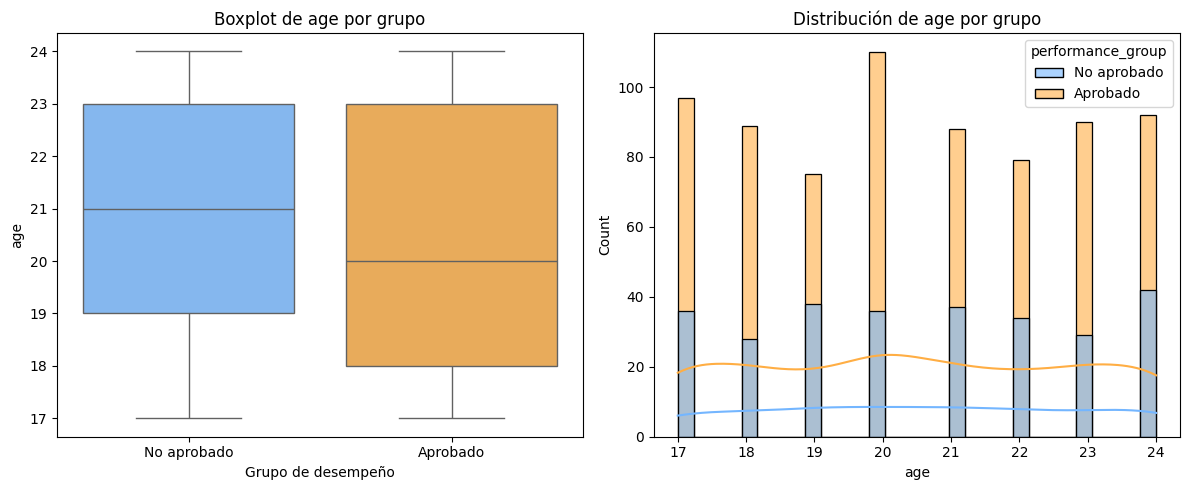

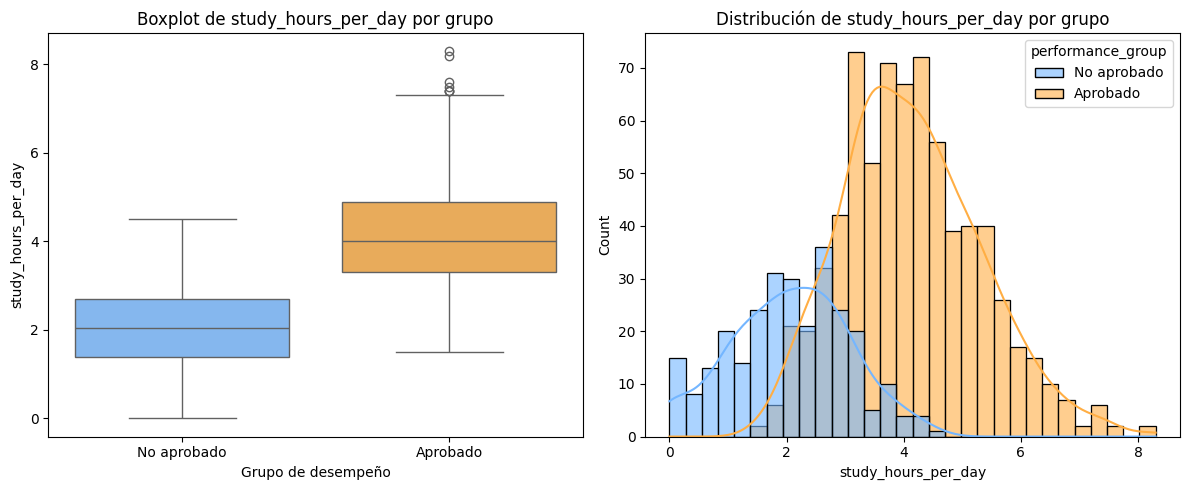

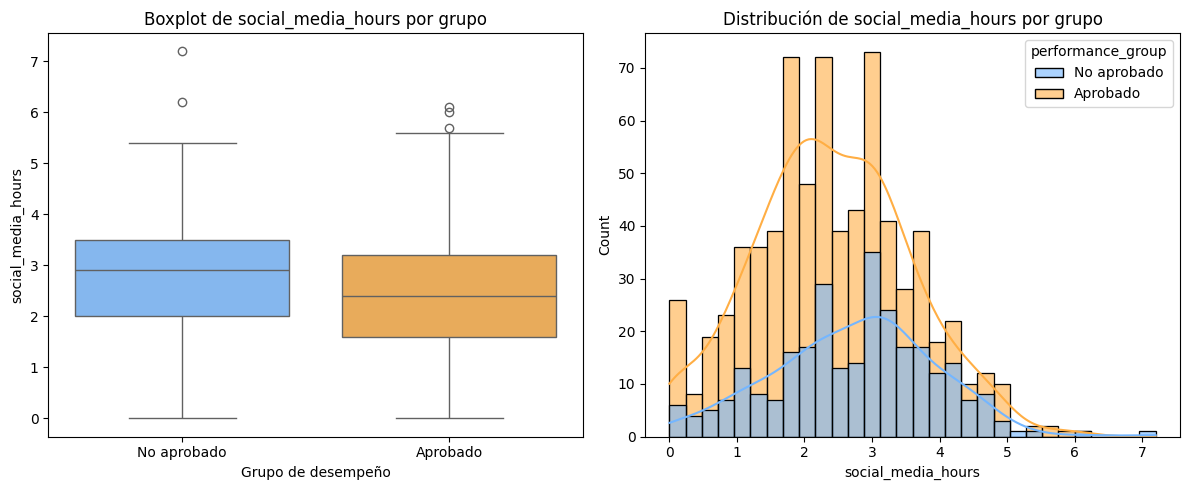

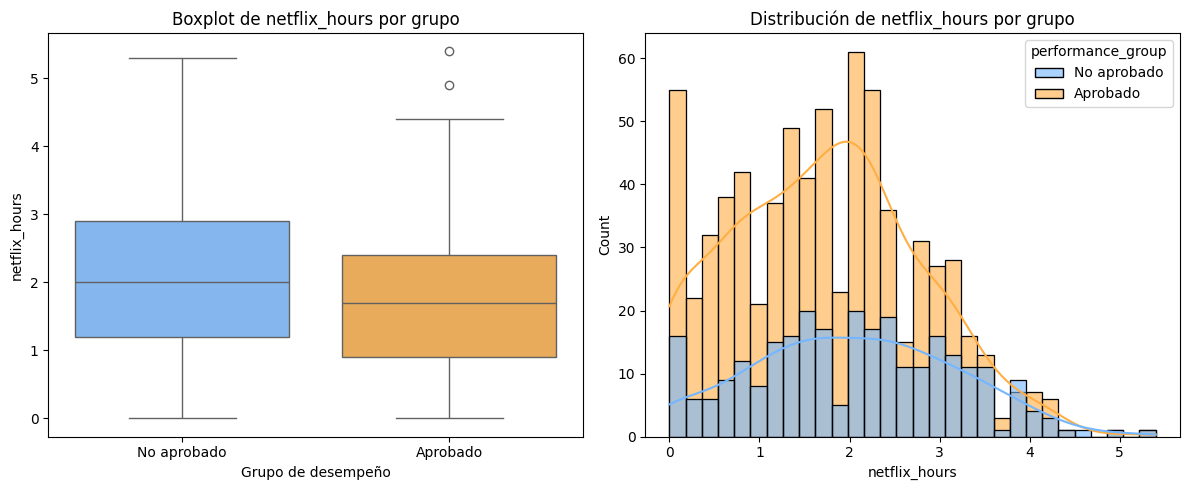

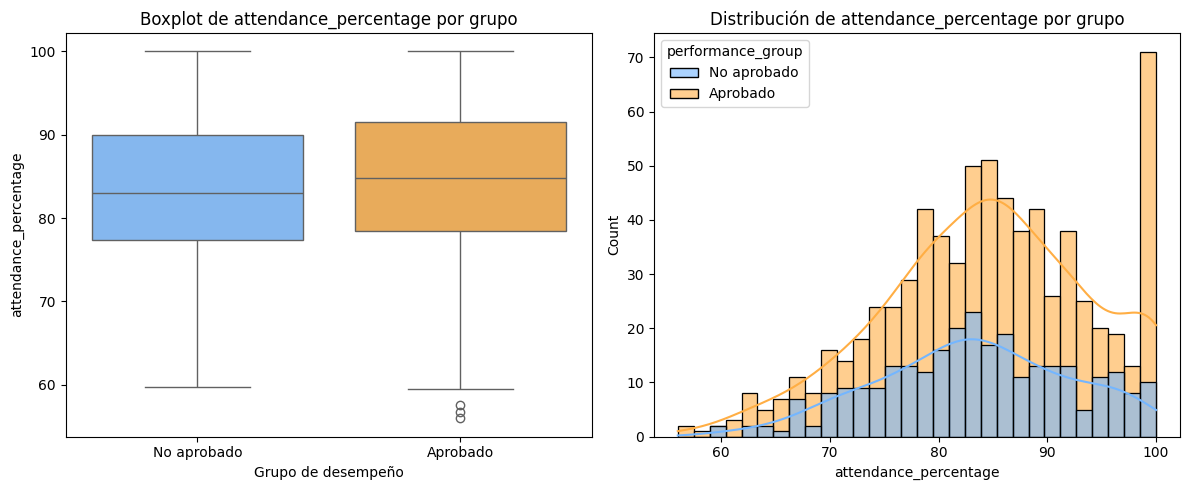

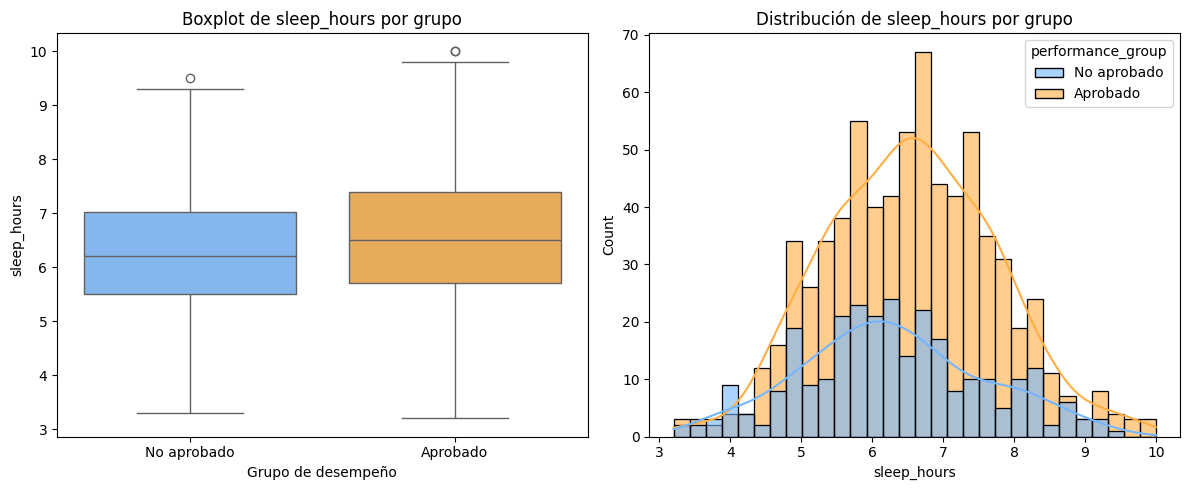

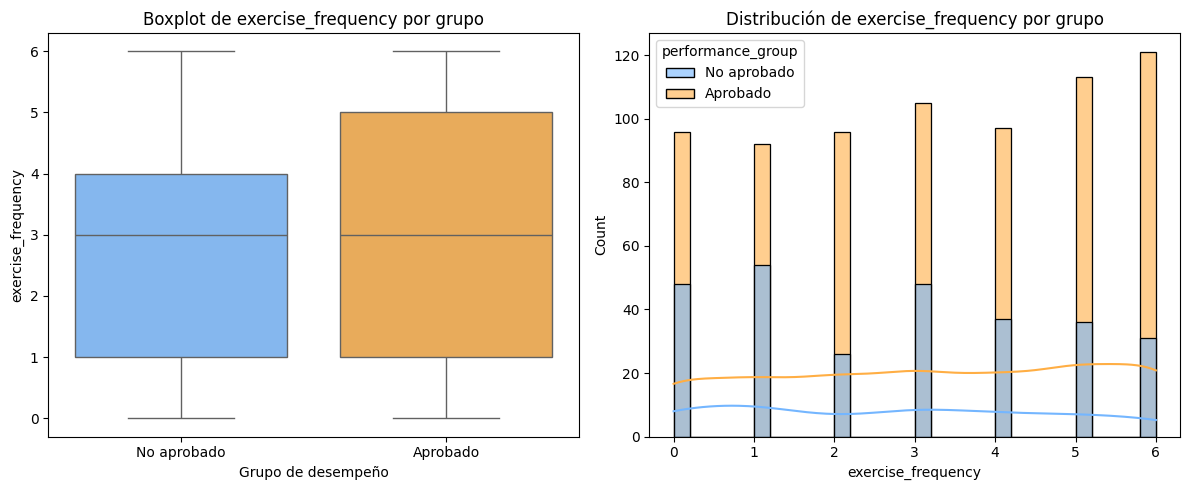

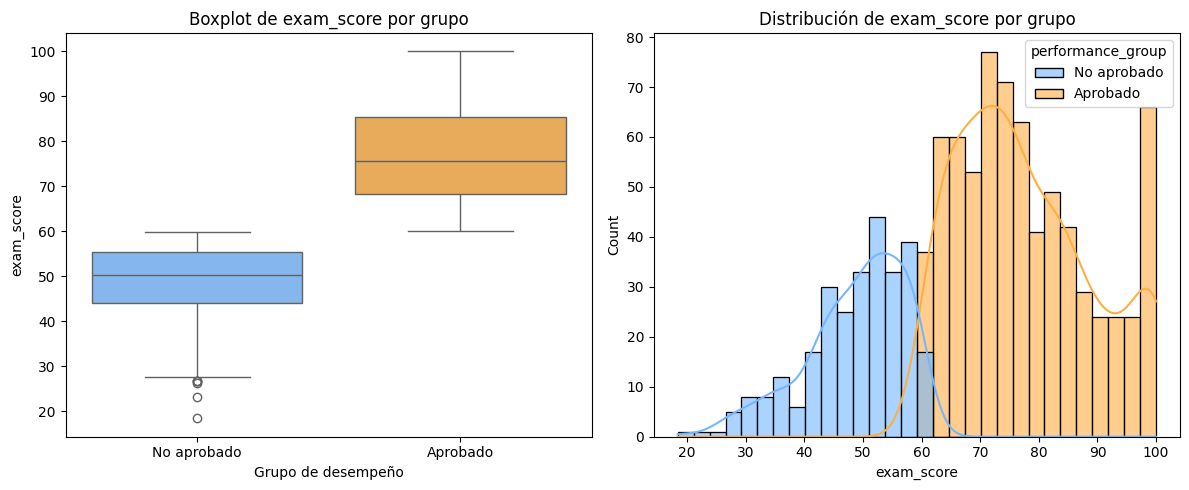

In [15]:
# -------------------------------
# VARIABLES CUANTITATIVAS
# -------------------------------
cols_cuantitativas = [
    'age', 'study_hours_per_day', 'social_media_hours',
       'netflix_hours', 'attendance_percentage',
       'sleep_hours', 'exercise_frequency',
       'exam_score']

for col in cols_cuantitativas:
    plt.figure(figsize=(12, 5))

    # Boxplot comparativo
    plt.subplot(1, 2, 1)
    sns.boxplot(x="performance_group", y=col, data=df_habits,
                hue="performance_group",
                palette={"Aprobado":"#ffae44", "No aprobado":"#74b6ff"},
                 dodge=False, legend=False)
    plt.title(f"Boxplot de {col} por grupo")
    plt.xlabel("Grupo de desempeño")
    plt.ylabel(col)

    # Histograma comparativo
    plt.subplot(1, 2, 2)
    sns.histplot(data=df_habits, x=col, hue="performance_group",
                 bins=30, kde=True, palette={"Aprobado":"#ffae44", "No aprobado":"#74b6ff"}, alpha=0.6)
    plt.title(f"Distribución de {col} por grupo")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

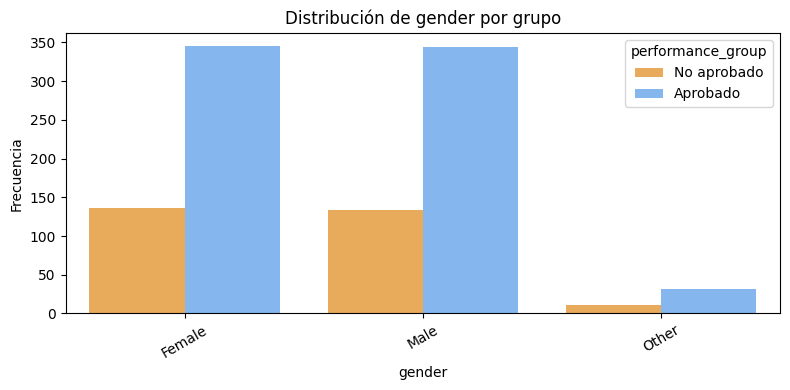

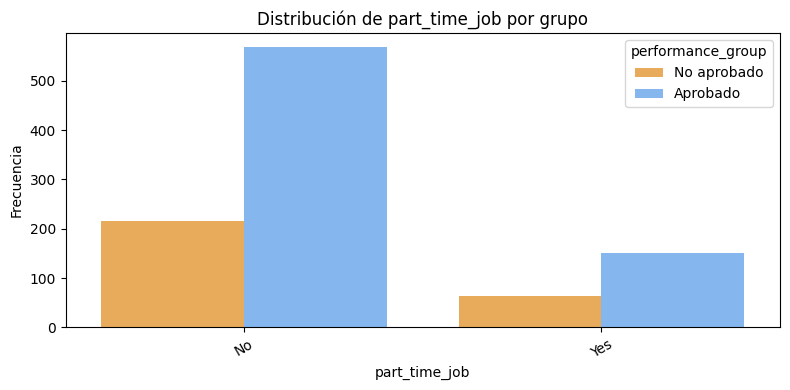

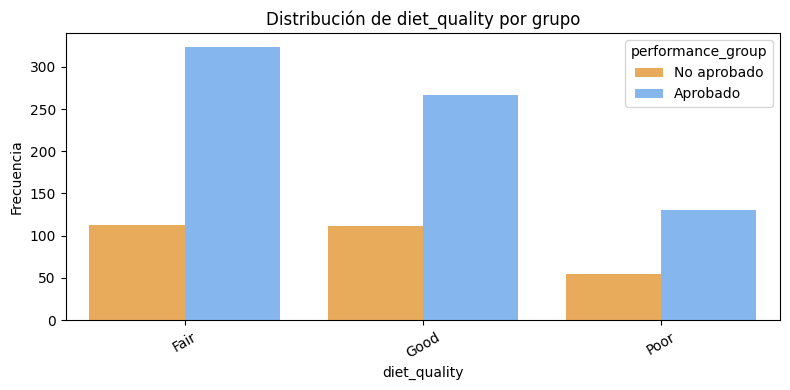

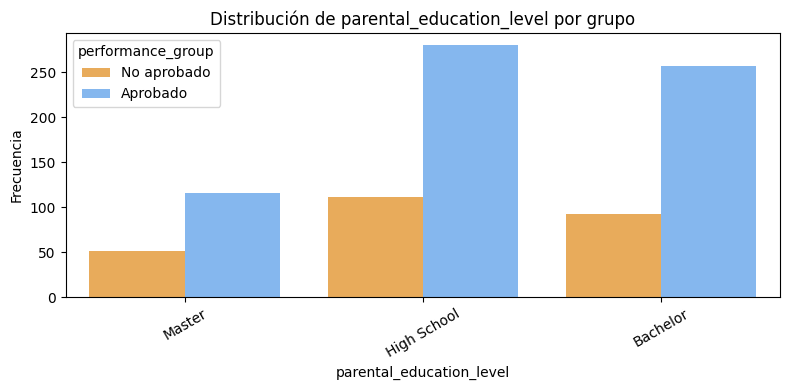

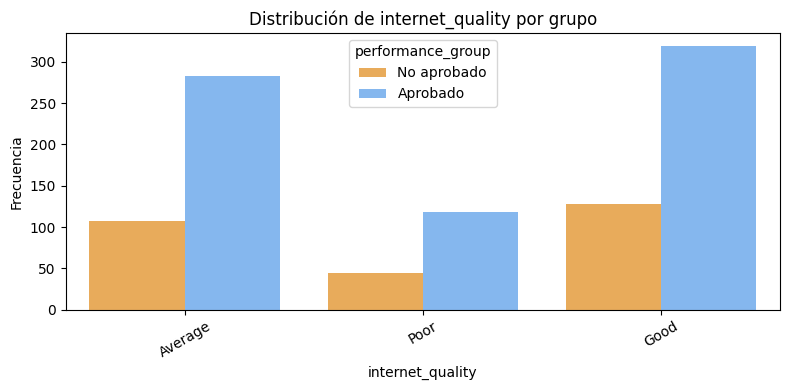

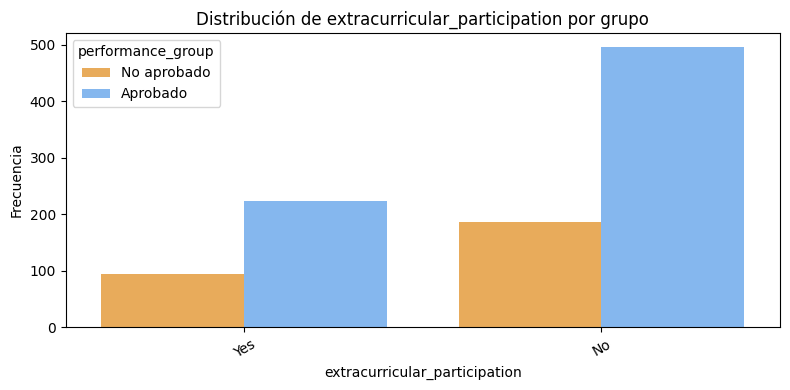

In [16]:
# -------------------------------
# VARIABLES CUALITATIVAS
# -------------------------------
cols_cualitativas = [
     'gender', 'part_time_job', 'diet_quality', 'parental_education_level',
     'internet_quality', 'extracurricular_participation'
]

for col in cols_cualitativas:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, hue="performance_group", data=df_habits,
                  palette=["#ffae44", "#74b6ff"])
    plt.title(f"Distribución de {col} por grupo")
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()